# Aufgabe 3

## Aufbau und Messungen

In der dritten Aufgabe wurde die Spannungsquelle durch eine Solarzelle ersetzt. Auch bei diesem Stromkreis haben wir die Spannung und die Stromstärke gemessen und dabei den Lastwiderstand immer weiter erhöht. Somit können wir schonmal das Verhältnis von U zu I in einem Plot darstellen.

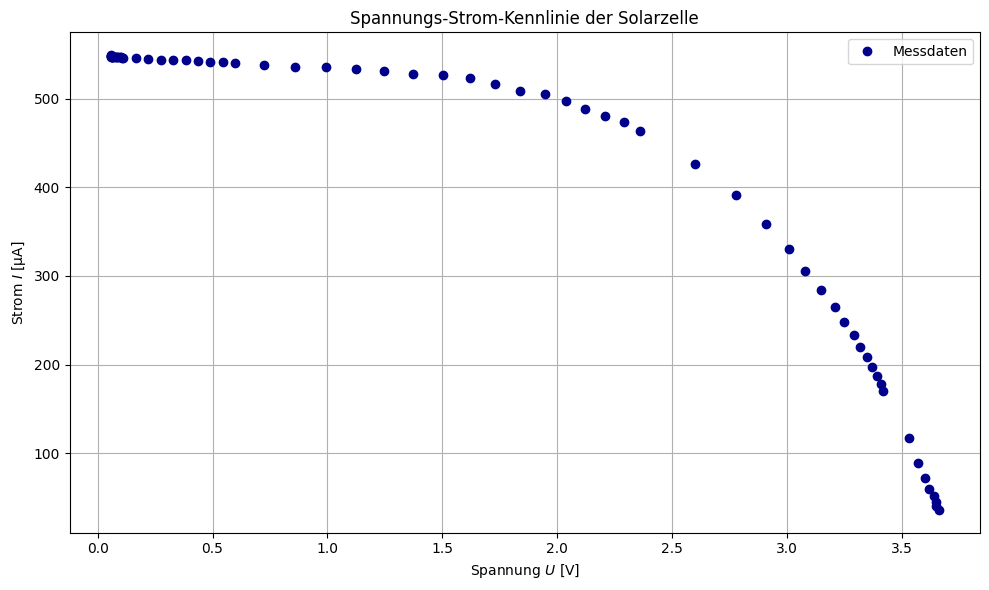

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# CSV-Daten einlesen
df = pd.read_csv("Daten/Aufgabe_3_Daten.csv")
df.columns = ['R_L[Ohm]', 'I[mA]', 'U[mV]', 'Messbereich']

# Einheiten anpassen
df['U[V]'] = df['U[mV]'] / 1000  # mV -> V
df['I[A]'] = df['I[mA]'] / 1000  # mA -> A
df['P[W]'] = df['U[V]'] * df['I[A]']  # Leistung berechnen

# Arbeits-/Maximumpunkt bestimmen
idx_max = df['P[W]'].idxmax()
arbeits_widerstand = df.loc[idx_max, 'R_L[Ohm]']
arbeits_spannung = df.loc[idx_max, 'U[V]']
arbeits_strom = df.loc[idx_max, 'I[A]']
arbeits_leistung = df.loc[idx_max, 'P[W]']



# U-I-Plot
plt.figure(figsize=(10, 6))
plt.plot(df['U[V]'], df['I[A]'] * 1e6, 'o', color='darkblue', label='Messdaten')
#plt.plot(df['U[V]'], df['I[A]'] * 1e6, '-', color='red', label='Kennlinie')
plt.xlabel('Spannung $U$ [V]')
plt.ylabel('Strom $I$ [µA]')
plt.title('Spannungs-Strom-Kennlinie der Solarzelle')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

import pandas as pd
arbeitsdaten = pd.DataFrame({
    'Arbeitspunkt-Spannung [V]': [arbeits_spannung],
    'Arbeitspunkt-Strom [A]': [arbeits_strom],
    'Arbeitspunkt-Leistung [W]': [arbeits_leistung],
    'Lastwiderstand R_max [Ohm]': [arbeits_widerstand]
})


Wenn wir nun den Arbeitspunkt bestimmen wollen, müssen wir die Leistung bei den verschiedenen Widerständen berechnen. Dafür nutzen wir die Formel für die Leistung:
$$P = U \cdot I$$
Wir wissen auch, dass am Arbeitspunkt die Leistung maximal ist. Diesen Punkt können wir bestimmen, indem wir den maximalen Wert für unsere Leistung nutzen.

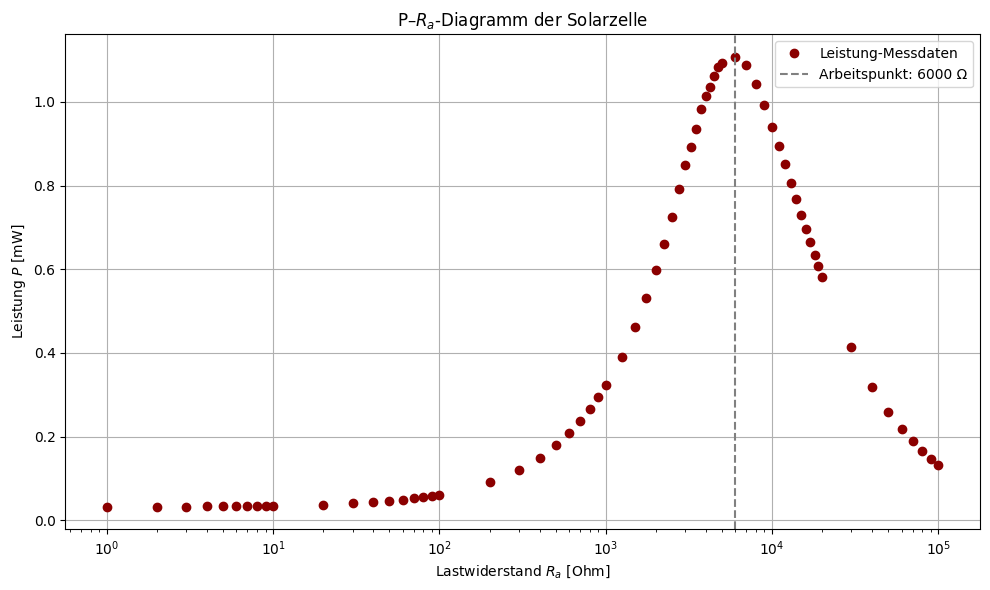

   Arbeitspunkt-Spannung [V]  Arbeitspunkt-Strom [A]  \
0                        2.6                0.000426   

   Arbeitspunkt-Leistung [W]  Lastwiderstand R_max [Ohm]  
0                   0.001108                        6000  


In [40]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# CSV-Daten einlesen
df = pd.read_csv("Daten/Aufgabe_3_Daten.csv")
df.columns = ['R_L[Ohm]', 'I[mA]', 'U[mV]', 'Messbereich']

# Einheiten anpassen
df['U[V]'] = df['U[mV]'] / 1000  # mV -> V
df['I[A]'] = df['I[mA]'] / 1000  # mA -> A
df['P[W]'] = df['U[V]'] * df['I[A]']  # Leistung berechnen

# Arbeits-/Maximumpunkt bestimmen
idx_max = df['P[W]'].idxmax()
arbeits_widerstand = df.loc[idx_max, 'R_L[Ohm]']
arbeits_spannung = df.loc[idx_max, 'U[V]']
arbeits_strom = df.loc[idx_max, 'I[A]']
arbeits_leistung = df.loc[idx_max, 'P[W]']




# P-Ra-Plot
plt.figure(figsize=(10, 6))
plt.plot(df['R_L[Ohm]'], df['P[W]'] * 1000, 'o', color='darkred', label='Leistung-Messdaten')
#plt.plot(df['R_L[Ohm]'], df['P[W]'] * 1000, '-', color='orange', label='Leistung-Linie')
plt.axvline(x=arbeits_widerstand, linestyle='--', color='gray', label=f'Arbeitspunkt: {arbeits_widerstand:.0f} Ω')
plt.xlabel('Lastwiderstand $R_a$ [Ohm]')
plt.ylabel('Leistung $P$ [mW]')
plt.xscale('log')
plt.title('P–$R_a$-Diagramm der Solarzelle')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

import pandas as pd
arbeitsdaten = pd.DataFrame({
    'Arbeitspunkt-Spannung [V]': [arbeits_spannung],
    'Arbeitspunkt-Strom [A]': [arbeits_strom],
    'Arbeitspunkt-Leistung [W]': [arbeits_leistung],
    'Lastwiderstand R_max [Ohm]': [arbeits_widerstand]
})

print(arbeitsdaten)

Bei 6000 $\Omega$ war unsere Leistung maximal. An diesem Punkt galt außerdem: 
$$ U = 2,6V; I = 0,426 mA; W = 1,108mW$$


## Fehlerbetrachtung

Durch das messen der Stromstärke, wurde das Amperemeter in Reihe geschaltet. Bei diesem haben wir vorher den Innenwiderstand für die verschiedenen Einstellungen gemessen. Bei [Aufgabe 3](#aufgabe-3) wurde es nur im Bereich bis maximal 2mA benutzt, bei welchem der Innenwiderstand 106,4 $\Omega$ ist. Außerdem wurde der Lastwiderstand $R_L$ mithilfe eines Dekadenwiderstands eingestellt, welcher eine Abweichung von $0,5%$ besitzt. Auch das Multimeter hat Abweichungen beim anzeigen, welche bei der Spannung $\pm$ (0,5% + 3 Digits) und bei der Stromstärke $\pm$ (0,8% + 3 Digits) beträgt.

Somit haben wir bei den Werten einige Abweichungen:
$$\Delta U = \pm (0,005 \cdot 2,6 + 0,003) = \pm 0,016V$$
$$\Delta I = \pm (0,008 \cdot 0,426 + 0,003) = \pm 0,0064mA$$
$$\Delta R = \pm 6000 \cdot 0,005 = \pm 30 \Omega$$

Dadurch, dass gilt $P=U\cdot I$, können wir durch die Abweichungen von U und I noch sagen:
$$ \left( \frac{\Delta P}{P} \right)^2 =  \left( \frac{\Delta U}{U} \right)^2 + \left( \frac{\Delta I}{I} \right)^2 \Rightarrow \Delta P = \pm 0.018 mW$$

Der Innenwiderstand des Amperemeters kann einfach zu $R_L$ addiert werden, da dieser in Reihe geschaltet wurde und verändert nur den Widerstand. Die Werte wurden gemessen, mit diesem Widerstand in Reihenschaltung.